# Drew's Test Code

## 1. Open data

In [48]:
import pandas as pd
import geopandas as gpd
import dask_geopandas as dgpd
import matplotlib.pyplot as plt

In [10]:
USA_48_STATES_BBOX = (-128.320313,24.367114,-65.039063,50.401515)

In [11]:
us_chargers = pd.read_csv('data/USChargingLocations.csv')
us_chargers = gpd.GeoDataFrame(us_chargers, geometry = gpd.points_from_xy(us_chargers['Longitude'], us_chargers['Latitude']))
us_chargers = us_chargers.cx[USA_48_STATES_BBOX[0]:USA_48_STATES_BBOX[2], USA_48_STATES_BBOX[1]:USA_48_STATES_BBOX[3]]

/var/folders/rd/8mbxk5gd789c6ptzwnn0v70w0000gn/T/ipykernel_90585/937759518.py:1: DtypeWarning: Columns (20,40,64,69) have mixed types. Specify dtype option on import or set low_memory=False.
  us_chargers = pd.read_csv('data/USChargingLocations.csv')


In [4]:
interstates = gpd.read_file('data/spatial_interstates_w_mobility.geojson', bbox = USA_48_STATES_BBOX)
interstates.shape

(875213, 99)

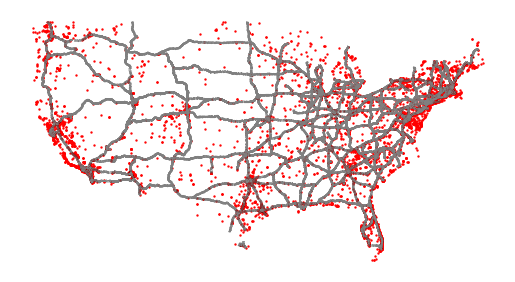

In [33]:
ax = interstates.plot(color='grey')
us_chargers.plot(ax = ax, color='red', markersize=0.5)
ax.set_axis_off()

In [14]:
us_chargers = us_chargers.set_crs('EPSG:4326')
us_chargers.crs == interstates.crs

True

## 2. Filter US Chargers

In [ ]:
interstates_1_mile = interstates.to_crs('EPSG:9311').buffer(1609.344)
# merged_interstates_buffer = interstates_1_mile.union_all()

/opt/anaconda3/lib/python3.12/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/lib/python3.12/site-packages/shapely/set_operations.py:553: RuntimeWarning: invalid value encountered in unary_union
  return lib.unary_union(collections, **kwargs)


In [31]:
chargers_by_interstate = gpd.sjoin(
    us_chargers.to_crs('EPSG:9311'), 
    gpd.GeoDataFrame(geometry=interstates_1_mile), 
    how="inner", 
    predicate="intersects"
).drop_duplicates(subset='ID')

In [47]:
# dask_chargers = dgpd.from_geopandas(us_chargers.to_crs('EPSG:9311'), npartitions=4)
# result = dask_chargers[dask_chargers.within(merged_interstates_buffer)]
# chargers_near_interstate = result.compute()

In [ ]:
# chargers_near_interstate = us_chargers.to_crs('EPSG:9311').within(merged_interstates_buffer)

In [69]:
interstates_simple = interstates.to_crs('EPSG:9311')
interstates_simple['geometry'] = interstates_simple.simplify(500)
interstates_simple = interstates_simple[interstates_simple.is_valid & ~interstates_simple.is_empty]

In [63]:
print(interstates_simple.total_bounds)

[-1952079.01431408 -2111246.854987    2399583.82264467   681288.33806999]


Interstate Bounds: [-1952079.01431408 -2111246.854987    2399583.82264467   681288.33806999]
Buffer Bounds: [-1991114.77669242 -2123178.28299194  2435499.134888     719872.73064663]


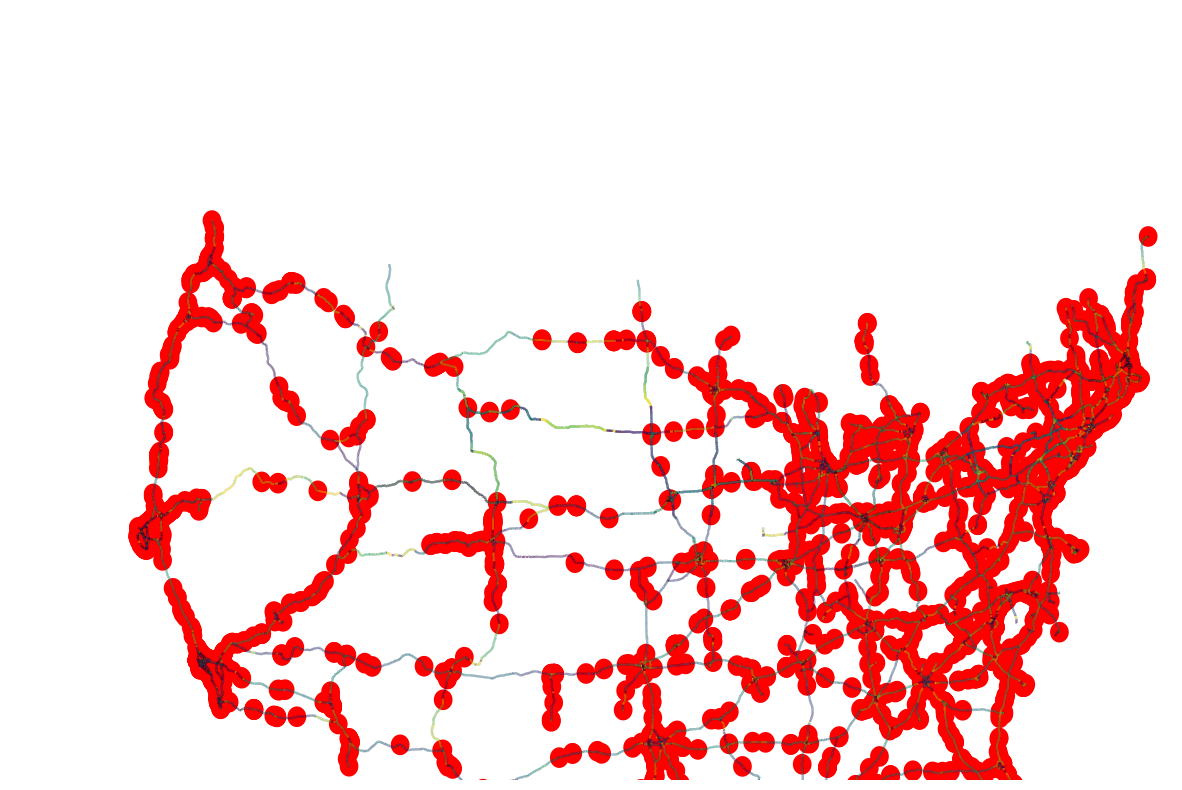

In [72]:
fig, ax = plt.subplots(figsize=(15, 10))

charger_buffers = chargers_by_interstate.to_crs('EPSG:9311')
charger_buffers = charger_buffers.buffer(1609.344 * 25)

charger_buffers = charger_buffers[charger_buffers.is_valid & ~charger_buffers.is_empty]

print("Interstate Bounds:", interstates_simple.total_bounds)
print("Buffer Bounds:", charger_buffers.total_bounds)

interstates_simple.plot(ax = ax,
                        alpha = 0.5, 
                        column='aadt', 
                        cmap='viridis',
                        legend=False)

charger_buffers.plot(ax = ax, color='red', markersize=0.5)

ax.set_xlim(-2500000, 2500000)
ax.set_ylim(-1500000, 1500000)

ax.set_aspect('auto')

ax.set_axis_off()

In [41]:
interstates.columns

Index(['aadt', 'aadt_combination', 'aadt_d', 'aadt_single_unit',
       'access_control', 'at_grade_other', 'base_thickness', 'base_type',
       'begin_point', 'counter_peak_lanes', 'county_id', 'cracking_percent',
       'cracking_percent_d', 'curves_a', 'curves_b', 'curves_c', 'curves_d',
       'curves_e', 'curves_f', 'dir_factor', 'dir_through_lanes', 'end_point',
       'facility_type', 'faulting', 'faulting_d', 'future_aadt_year',
       'f_system', 'future_aadt', 'grades_a', 'grades_b', 'grades_c',
       'grades_d', 'grades_e', 'grades_f', 'iri', 'iri_d', 'is_restricted',
       'k_factor', 'lane_width', 'last_overlay_thickness',
       'maintenance_operations', 'managed_lanes', 'managed_lanes_type',
       'median_type', 'median_width', 'nhfn', 'nhs', 'nn', 'number_signals',
       'ownership', 'pct_dh_combination', 'pct_dh_single_unit',
       'pct_green_time', 'pct_pass_sight', 'peak_lanes', 'peak_parking', 'psr',
       'psr_d', 'route_id', 'route_number', 'route_qualifier